### ESAM 495 Assignment 2: Quasi-Steady State Analysis & Thermodynamics

Author: Phoebe Kuang

Date: May 3, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import seaborn as sns
sns.set_style("whitegrid")
sns.set_theme(font_scale=1.5)

#### 1 Michaelis-Menten Simulation \& QSSA Limit

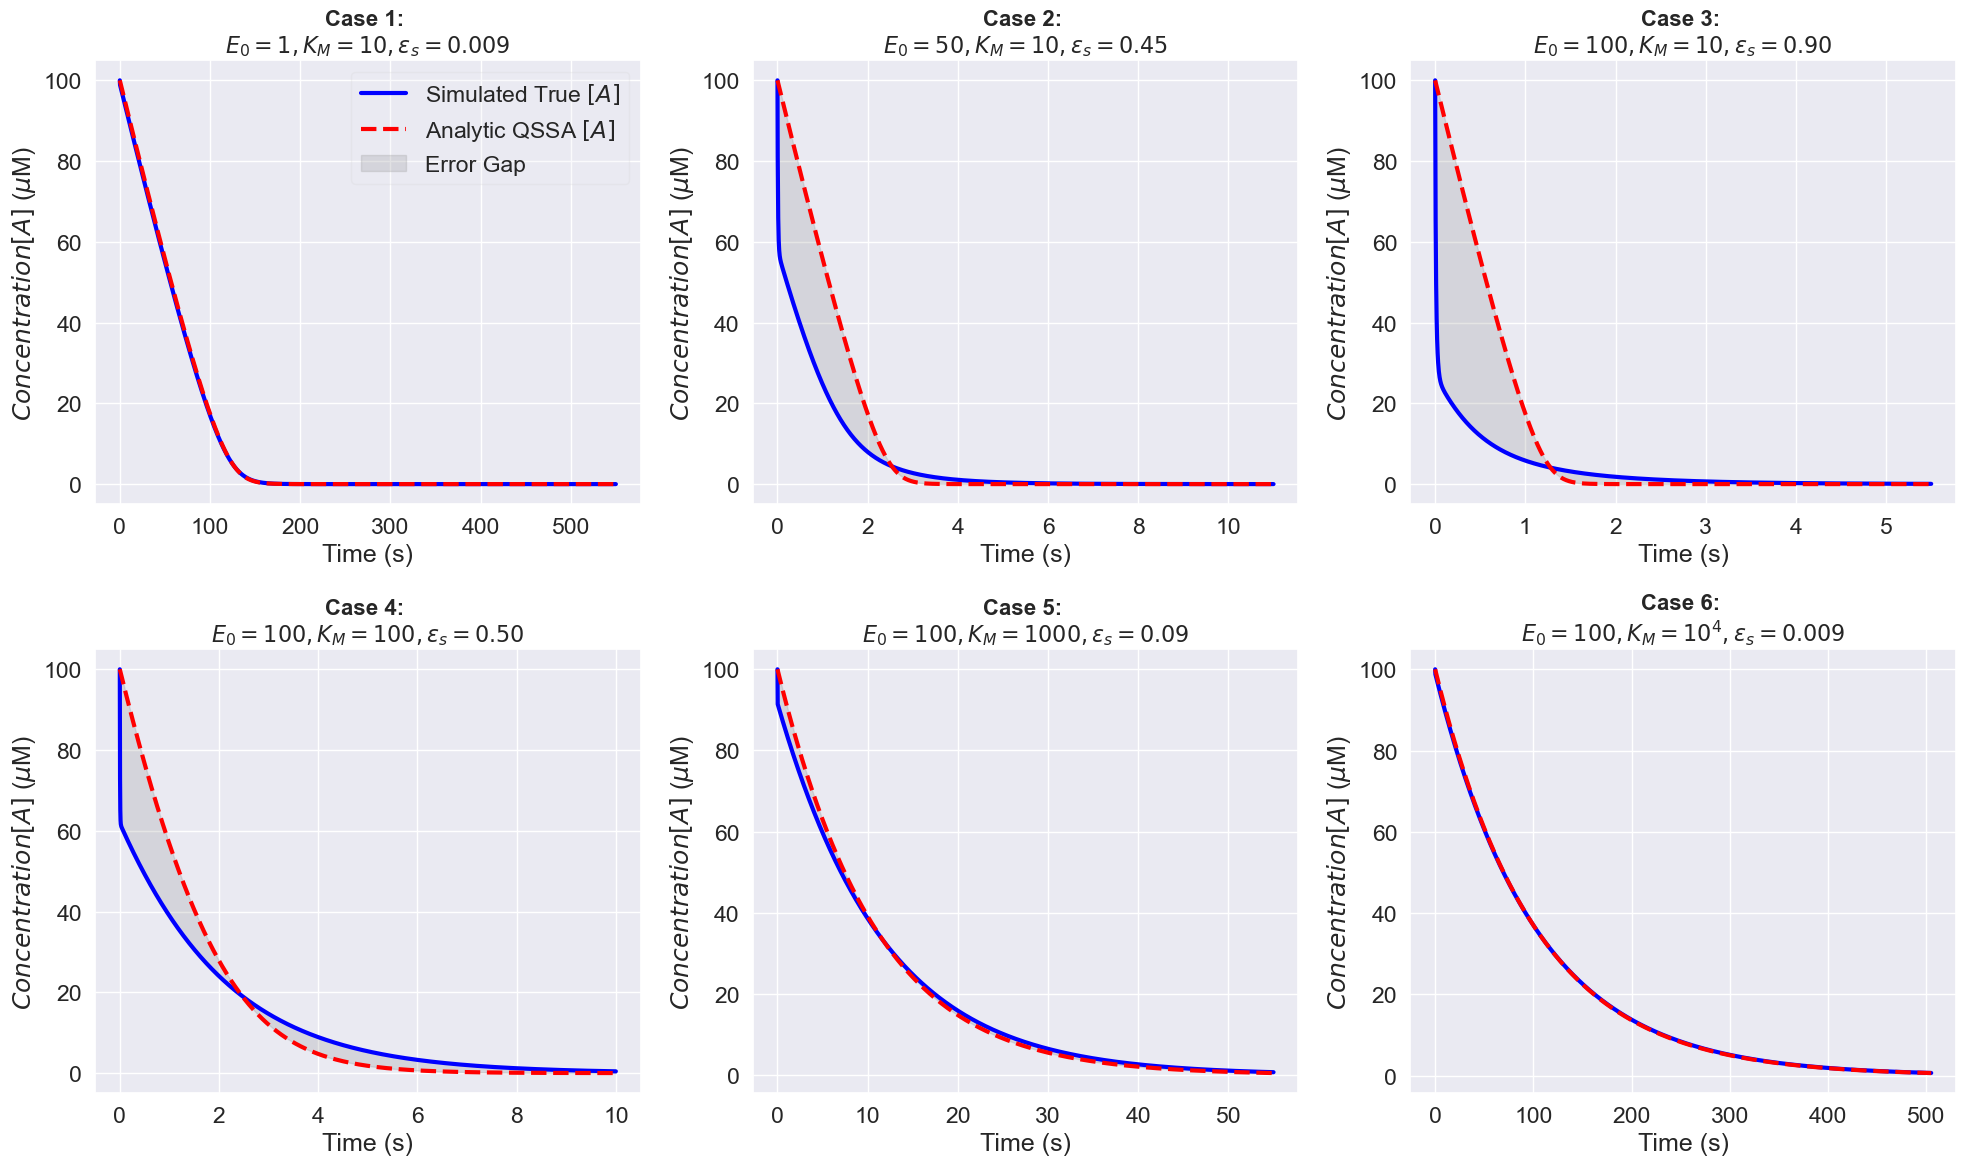

In [2]:
# True System
def true_system(y, t, kb, ku, k1, E0):
    A, AE1 = y
    dA_dt = -kb * A * (E0 - AE1) + ku * AE1
    dAE1_dt = kb * A * E0 - AE1 * (kb * A + ku + k1)
    return [dA_dt, dAE1_dt]

# QSSA System
def qssa_system(A, t, k1, E0, K_M):
    return -(k1 * E0 * A) / (K_M + A)

# Global Parameters
A0 = 100.0
k1 = 1.0 
kb = 1.0 # Fixed binding rate, we will adjust ku to change K_M

# 6  Cases
cases = [
    # ROW 1: Sweeping E0 to show Breakdown (Fixed K_M = 10)
    {'E0': 1.0,   'K_M': 10.0,    'title': 'Case 1: \n$E_0=1, K_M=10, \\epsilon_s = 0.009$'},
    {'E0': 50.0,  'K_M': 10.0,    'title': 'Case 2: \n$E_0=50, K_M=10, \\epsilon_s = 0.45$'},
    {'E0': 100.0, 'K_M': 10.0,    'title': 'Case 3: \n$E_0=100, K_M=10, \\epsilon_s = 0.90$'},
    
    # ROW 2: Sweeping K_M to show Segel Generalized epsilon (Fixed E0 = 100) ---
    {'E0': 100.0, 'K_M': 100.0,   'title': 'Case 4: \n$E_0=100, K_M=100, \\epsilon_s = 0.50$'},
    {'E0': 100.0, 'K_M': 1000.0,  'title': 'Case 5: \n$E_0=100, K_M=1000, \\epsilon_s = 0.09$'},
    {'E0': 100.0, 'K_M': 10000.0, 'title': 'Case 6: \n$E_0=100, K_M=10^4, \\epsilon_s = 0.009$'}
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, case in enumerate(cases):
    E0 = case['E0']
    K_M = case['K_M']
    ku = K_M * kb - k1 # Derive ku from K_M
    
    # Dynamically scale t_max
    # Reaction timescale t_s is roughly (K_M + A0) / (k1 * E0)
    t_max = 5.0 * (K_M + A0) / (k1 * E0)
    t = np.linspace(0, t_max, 2000)
    
    # Simulate True ODE
    y0 = [A0, 0.0]
    true_sol = odeint(true_system, y0, t, args=(kb, ku, k1, E0))
    A_true = true_sol[:, 0]
    
    # Simulate QSSA ODE
    A_qssa = odeint(qssa_system, A0, t, args=(k1, E0, K_M)).flatten()
    
    # Plotting
    ax = axes[i]
    ax.plot(t, A_true, label='Simulated True $[A]$', color='blue', lw=3)
    ax.plot(t, A_qssa, label='Analytic QSSA $[A]$', color='red', linestyle='--', lw=3)
    
    # Shade the error gap
    ax.fill_between(t, A_true, A_qssa, color='gray', alpha=0.2, label='Error Gap')
    
    ax.set_title(case['title'], weight='bold', fontsize=16)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('$Concentration [A]$ ($\mu$M)')
    
    if i == 0:
        ax.legend(framealpha=0.2, loc='upper right')

plt.tight_layout()
plt.show()

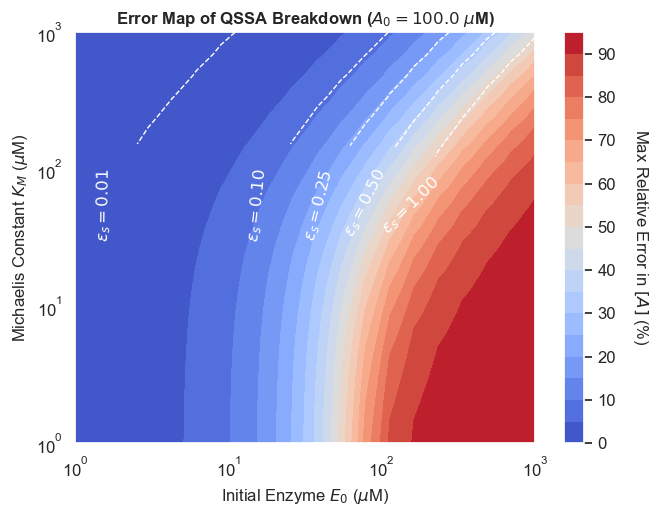

In [3]:
# Error Analysis (Max Relative Error vs. Segel Parameter)

# E0 and K_M sweep values
E0_vals = np.logspace(0, 3, 20)   # 1 to 1000
KM_vals = np.logspace(0, 3, 20)     # 1 to 1000

error_matrix = np.zeros((len(KM_vals), len(E0_vals)))
epsilon_matrix = np.zeros((len(KM_vals), len(E0_vals)))

# Run the sweep
for i, K_M in enumerate(KM_vals):
    for j, E0 in enumerate(E0_vals):
        ku = K_M * kb - k1
        if ku < 0: ku = 0 # Prevent negative unbinding rates
        
        # Calculate epsilon_s
        eps = E0 / (A0 + K_M)
        epsilon_matrix[i, j] = eps
        
        # Simulate
        t_max = 5.0 * (K_M + A0) / (k1 * E0)
        t = np.linspace(0, t_max, 500)
        
        true_sol = odeint(true_system, [A0, 0.0], t, args=(kb, ku, k1, E0))
        A_true = true_sol[:, 0]
        A_qssa = odeint(qssa_system, A0, t, args=(k1, E0, K_M)).flatten()
        
        # Calculate Max Relative Error (%)
        # Ignore points where A_true is virtually zero to avoid div by zero
        valid_idx = A_true > 1e-3
        if np.any(valid_idx):
            max_err = np.max(np.abs(A_true[valid_idx] - A_qssa[valid_idx]) / A0) * 100
        else:
            max_err = 0
            
        error_matrix[i, j] = max_err

# Plotting
fig, ax = plt.subplots(figsize=(7, 5.5))

# Error Heatmap
X, Y = np.meshgrid(E0_vals, KM_vals)
contour_fill = ax.contourf(X, Y, error_matrix, levels=20, cmap='coolwarm')
cbar = fig.colorbar(contour_fill, ax=ax)
cbar.set_label('Max Relative Error in $[A]$ (%)', rotation=270, labelpad=25, fontsize=12)
cbar.ax.tick_params(labelsize=12)

# Overlay epsilon_s contours (White lines)
eps_levels = [0.01, 0.1, 0.25, 0.5, 1.0]
contour_lines = ax.contour(X, Y, epsilon_matrix, levels=eps_levels, colors='white', linewidths=1, linestyles='dashed')
ax.clabel(contour_lines, inline=True, fontsize=12, fmt=r'$\epsilon_s = %1.2f$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel('Initial Enzyme $E_0$ ($\mu$M)', fontsize=12)
ax.set_ylabel('Michaelis Constant $K_M$ ($\mu$M)', fontsize=12)
ax.set_title(f'Error Map of QSSA Breakdown ($A_0 = {A0}$ $\mu$M)', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

#### 3 Thermodynamic Analysis

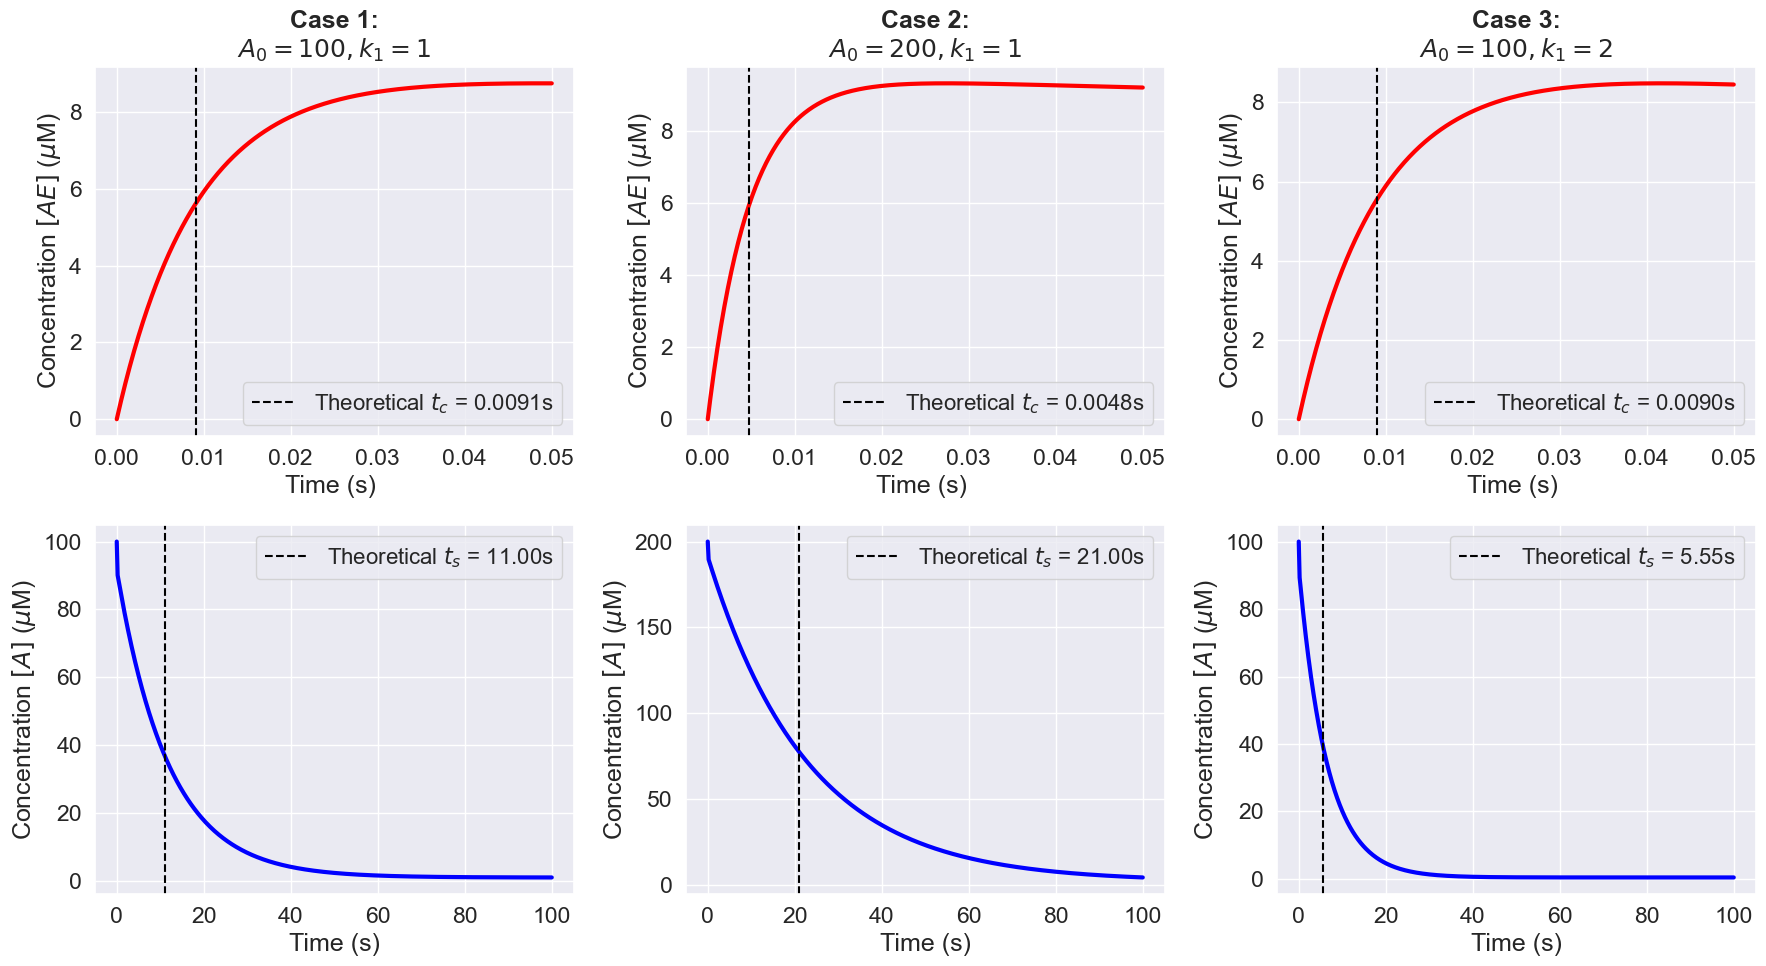

In [4]:

# The Full Reversible System
def reversible_system(y, t, kb, ku, k1, k_rev, E0):
    A, AE, BE, B = y
    E = E0 - AE - BE
    
    dA_dt = -kb * A * E + ku * AE
    dAE_dt = kb * A * E - (ku + k1) * AE + k_rev * BE
    dBE_dt = k1 * AE - (k_rev + ku) * BE + kb * B * E
    dB_dt = ku * BE - kb * B * E
    
    return [dA_dt, dAE_dt, dBE_dt, dB_dt]

# Global Parameters
E0 = 10.0
kb = 1.0
ku = 9.0
k_rev = 0.01  # Keep k_1 >> k_{-1}

cases = [
    {'A0': 100.0, 'k1': 1.0, 'title': 'Case 1:\n$A_0=100, k_1=1$'},
    {'A0': 200.0, 'k1': 1.0, 'title': 'Case 2:\n$A_0=200, k_1=1$'},
    {'A0': 100.0, 'k1': 2.0, 'title': 'Case 3:\n$A_0=100, k_1=2$'}
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, case in enumerate(cases):
    A0 = case['A0']
    k1 = case['k1']
    
    # Calculate Theoretical Timescales
    K_M = (ku + k1) / kb
    tc_theory = 1.0 / (kb * A0 + ku + k1)
    ts_theory = (A0 + K_M) / (k1 * E0)
    
    # 1. Simulate Fast Transient (Microseconds)
    t_fast = np.linspace(0, 0.05, 500)
    sol_fast = odeint(reversible_system, [A0, 0, 0, 0], t_fast, args=(kb, ku, k1, k_rev, E0))
    AE_fast = sol_fast[:, 1]
    
    # 2. Simulate Slow Depletion (Seconds)
    t_slow = np.linspace(0, 100, 500)
    sol_slow = odeint(reversible_system, [A0, 0, 0, 0], t_slow, args=(kb, ku, k1, k_rev, E0))
    A_slow = sol_slow[:, 0]
    
    # ROW 1: Fast Timescale (AE vs t)
    ax_c = axes[0, i]
    ax_c.plot(t_fast, AE_fast, color='red', lw=3)
    ax_c.axvline(tc_theory, color='black', linestyle='--', label=f'Theoretical $t_c$ = {tc_theory:.4f}s')
    ax_c.set_title(case['title'], weight='bold')
    ax_c.set_xlabel('Time (s) ')
    ax_c.set_ylabel('Concentration $[AE]$ ($\mu$M)')
    ax_c.legend(fontsize=16)
    
    # ROW 2: Slow Timescale (A vs t) 
    ax_s = axes[1, i]
    ax_s.plot(t_slow, A_slow, color='blue', lw=3)
    ax_s.axvline(ts_theory, color='black', linestyle='--', label=f'Theoretical $t_s$ = {ts_theory:.2f}s')
    ax_s.set_xlabel('Time (s)')
    ax_s.set_ylabel('Concentration $[A]$ ($\mu$M)')
    ax_s.legend(fontsize=16)

plt.tight_layout()
plt.show()